In [ ]:
import random
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

def digit_to_int(digit, base):
    """
    Convert a digit (0-9, A-R for base up to 28) to its integer value.
    For bases > 10, digits beyond 9 are represented as letters A=10, B=11, etc.
    """
    if isinstance(digit, int):
        return digit
    if digit.isdigit():
        return int(digit)
    # Handle letters A-R for bases up to 28
    return ord(digit.upper()) - ord('A') + 10

def int_to_digit(value, base):
    """
    Convert an integer value to its digit representation.
    Returns string for values >= 10 (A, B, C, etc.)
    """
    if value < 10:
        return str(value)
    # Convert to letters for values >= 10
    return chr(ord('A') + value - 10)

def number_to_digits(num_str, base):
    """
    Convert a string representation of a number to a list of integer digits.
    """
    return [digit_to_int(d, base) for d in num_str]

def digits_to_number(digits, base):
    """
    Convert a list of digits to a string representation of the number.
    """
    return ''.join(int_to_digit(d, base) for d in digits)

def are_all_digits_same(number_str, base):
    """
    Check if all digits in the number are identical.
    Returns True if all digits are the same, False otherwise.
    """
    digits = number_to_digits(number_str, base)
    if len(digits) <= 1:
        return True
    first_digit = digits[0]
    return all(digit == first_digit for digit in digits)

def sort_digits_desc(digits):
    """Sort digits in descending order."""
    return sorted(digits, reverse=True)

def sort_digits_asc(digits):
    """Sort digits in ascending order."""
    return sorted(digits)

def compute_kaprekar_step(number_str, base):
    """
    Perform one iteration of Kaprekar's routine:
    1. Sort digits in descending order to form largest number
    2. Sort digits in ascending order to form smallest number
    3. Subtract smallest from largest
    4. Pad result to original length if necessary

    Note: If all digits are the same, the result will be zero.
    """
    # Convert string to digit list
    digits = number_to_digits(number_str, base)
    n = len(digits)

    # Check if all digits are the same (this would lead to zero)
    if are_all_digits_same(number_str, base):
        # Return a string of zeros
        return digits_to_number([0] * n, base)

    # Sort digits in descending and ascending order
    desc_digits = sort_digits_desc(digits)
    asc_digits = sort_digits_asc(digits)

    # Convert to numbers (as integer arrays for arithmetic)
    desc_value = 0
    asc_value = 0

    # Convert from base to decimal for subtraction
    for i, digit in enumerate(desc_digits):
        desc_value += digit * (base ** (n - 1 - i))

    for i, digit in enumerate(asc_digits):
        asc_value += digit * (base ** (n - 1 - i))

    # Perform subtraction
    result_value = desc_value - asc_value

    # Convert result back to target base representation
    result_digits = []
    temp_value = result_value
    for _ in range(n):
        result_digits.insert(0, temp_value % base)
        temp_value //= base

    # Pad with leading zeros if necessary
    while len(result_digits) < n:
        result_digits.insert(0, 0)

    return digits_to_number(result_digits, base)

def is_kaprekar_constant(number_str, base, max_iterations=1000):
    """
    Determine if a number leads to a Kaprekar constant (fixed point or cycle)
    Returns: (is_constant, constant_or_cycle, iterations_to_reach)
    """
    seen = {}
    current = number_str
    iteration = 0

    while iteration < max_iterations:
        if current in seen:
            # Found a cycle
            cycle_start = seen[current]
            cycle = list(seen.keys())[cycle_start:] + [current]
            # Check if it's a fixed point (cycle of length 1)
            is_fixed_point = (len(cycle) == 1)
            return (True, cycle, iteration)

        seen[current] = iteration
        current = compute_kaprekar_step(current, base)
        iteration += 1

    return (False, None, max_iterations)

def generate_random_number(n_digits, base):
    """
    Generate a random n-digit number in given base.
    First digit cannot be zero.
    Also ensures that NOT all digits are the same (to avoid trivial zero case).
    """
    max_attempts = 100  # Prevent infinite loop in edge cases

    for attempt in range(max_attempts):
        digits = []
        # First digit: 1 to base-1
        digits.append(random.randint(1, base - 1))
        # Remaining digits: 0 to base-1
        for _ in range(n_digits - 1):
            digits.append(random.randint(0, base - 1))

        # Convert to string for checking
        number_str = digits_to_number(digits, base)

        # Reject numbers where all digits are the same
        if not are_all_digits_same(number_str, base):
            return number_str

    # Fallback: generate a number that's guaranteed to have different digits
    # This is a safety measure for very small bases or digit lengths
    digits = list(range(min(base, n_digits)))
    while len(digits) < n_digits:
        digits.append(0)
    random.shuffle(digits)
    # Ensure first digit isn't zero
    if digits[0] == 0:
        for i in range(1, len(digits)):
            if digits[i] != 0:
                digits[0], digits[i] = digits[i], digits[0]
                break
    return digits_to_number(digits, base)

def generate_all_possible_numbers(n_digits, base):
    """
    Generate ALL possible n-digit numbers in given base (for exhaustive analysis).
    Excludes numbers where all digits are the same.
    This is useful for small n and base combinations.
    """
    from itertools import product

    valid_numbers = []
    # Generate all possible digit combinations
    for digits_tuple in product(range(base), repeat=n_digits):
        # Skip if first digit is zero (not an n-digit number)
        if digits_tuple[0] == 0:
            continue

        # Convert to string for checking
        number_str = digits_to_number(list(digits_tuple), base)

        # Skip numbers where all digits are the same
        if are_all_digits_same(number_str, base):
            continue

        valid_numbers.append(number_str)

    return valid_numbers

def monte_carlo_kaprekar(n_digits, base, num_samples=1000, exhaustive=False):
    """
    Run Monte Carlo simulation to find Kaprekar constant(s) for given (n, base).

    Parameters:
    - n_digits: number of digits
    - base: base of the number system (2 to 28)
    - num_samples: number of random starting numbers to test
    - exhaustive: if True, test ALL possible numbers (ignores num_samples)

    Returns:
    - Dictionary with statistics about found constants/cycles
    """
    print(f"Running {'exhaustive' if exhaustive else 'Monte Carlo'} analysis for {n_digits}-digit numbers in base {base}")

    if exhaustive:
        # Generate all possible numbers
        all_numbers = generate_all_possible_numbers(n_digits, base)
        num_samples = len(all_numbers)
        print(f"Testing all {num_samples} possible numbers (excluding numbers with all identical digits)...")
        numbers_to_test = all_numbers
    else:
        print(f"Testing {num_samples} random numbers (excluding numbers with all identical digits)...")
        numbers_to_test = [generate_random_number(n_digits, base) for _ in range(num_samples)]

    constant_stats = Counter()
    iteration_stats = []
    rejected_samples = 0  # Count numbers that were all same digits (should be zero now)

    for i, start_number in enumerate(numbers_to_test):
        if (i + 1) % max(1, num_samples // 10) == 0:
            print(f"Progress: {i+1}/{num_samples} samples processed")

        # Optional: Double-check that we're not testing invalid numbers
        if are_all_digits_same(start_number, base):
            rejected_samples += 1
            continue

        # Run Kaprekar routine
        is_constant, constant_cycle, iterations = is_kaprekar_constant(start_number, base)

        if is_constant:
            # Convert cycle to readable format
            cycle_str = ' -> '.join(constant_cycle)
            constant_stats[cycle_str] += 1
            iteration_stats.append(iterations)

    if rejected_samples > 0:
        print(f"Warning: {rejected_samples} numbers with all identical digits were skipped")

    # Calculate statistics
    results = {
        'n_digits': n_digits,
        'base': base,
        'num_samples': num_samples,
        'valid_samples': num_samples - rejected_samples,
        'exhaustive': exhaustive,
        'constants_found': len(constant_stats),
        'most_common_constant': constant_stats.most_common(1)[0] if constant_stats else None,
        'constant_distribution': dict(constant_stats),
        'avg_iterations': np.mean(iteration_stats) if iteration_stats else 0,
        'std_iterations': np.std(iteration_stats) if iteration_stats else 0
    }

    return results

def plot_results(results, save_plot=False):
    """
    Visualize the simulation results.
    """
    if not results['constant_distribution']:
        print("No constants/cycles found to plot")
        return

    constants = list(results['constant_distribution'].keys())
    frequencies = list(results['constant_distribution'].values())

    plt.figure(figsize=(14, 6))

    # Bar chart of constant frequencies
    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(constants)), frequencies, tick_label=constants)
    plt.xlabel('Kaprekar Constants/Cycles')
    plt.ylabel('Frequency')
    title = f'Distribution of Kaprekar Constants\n{results["n_digits"]}-digit numbers in base {results["base"]}'
    if results['exhaustive']:
        title += f'\n(Exhaustive analysis of {results["valid_samples"]} numbers)'
    else:
        title += f'\n(Monte Carlo with {results["num_samples"]} samples)'
    plt.title(title)
    plt.xticks(rotation=45, ha='right')

    # Add value labels on bars
    for i, (bar, freq) in enumerate(zip(bars, frequencies)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{freq}\n({freq/results["valid_samples"]*100:.1f}%)',
                 ha='center', va='bottom')

    # Pie chart of constant distribution
    plt.subplot(1, 2, 2)
    plt.pie(frequencies, labels=constants, autopct='%1.1f%%')
    plt.title(f'Proportion of Constants Found\n(Valid samples: {results["valid_samples"]})')

    plt.tight_layout()

    if save_plot:
        filename = f'kaprekar_n{results["n_digits"]}_b{results["base"]}'
        filename += '_exhaustive' if results['exhaustive'] else '_montecarlo'
        filename += '.png'
        plt.savefig(filename)
        print(f"Plot saved as {filename}")

    plt.show()

def verify_kaprekar_routine(n_digits, base, test_number=None):
    """
    Interactive function to step through Kaprekar's routine for a specific number.
    Useful for understanding the process and verification.
    """
    if test_number is None:
        test_number = generate_random_number(n_digits, base)

    print(f"\n" + "=" * 60)
    print(f"STEP-BY-STEP KAPREKAR ROUTINE VERIFICATION")
    print("=" * 60)
    print(f"Starting number: {test_number} (base {base})")
    print(f"Number of digits: {n_digits}")

    if are_all_digits_same(test_number, base):
        print("\nWARNING: All digits are the same!")
        print("Kaprekar's routine would immediately go to zero as:")
        print(f"  Largest: {test_number}")
        print(f"  Smallest: {test_number}")
        print(f"  Difference: 0")
        return

    current = test_number
    iteration = 0
    seen = set()

    while current not in seen:
        seen.add(current)
        digits = number_to_digits(current, base)
        desc_digits = sort_digits_desc(digits)
        asc_digits = sort_digits_asc(digits)

        desc_str = digits_to_number(desc_digits, base)
        asc_str = digits_to_number(asc_digits, base)

        print(f"\nIteration {iteration + 1}:")
        print(f"  Current: {current}")
        print(f"  Largest: {desc_str}")
        print(f"  Smallest: {asc_str}")

        next_number = compute_kaprekar_step(current, base)
        print(f"  Difference: {next_number}")

        current = next_number
        iteration += 1

        if iteration > 100:
            print("\nReached maximum iterations (100). Possible infinite loop?")
            break

    print(f"\nReached cycle after {iteration} iterations!")
    print(f"Cycle detected: {' -> '.join(list(seen) + [current])}")

# Example usage and demonstration
if __name__ == "__main__":
    print("=" * 60)
    print("KAPREKAR ROUTINE MONTE CARLO SIMULATION")
    print("(Excluding numbers where all digits are identical)")
    print("=" * 60)

    try:
        # Get user input
        n = int(input("\nEnter number of digits: "))
        b = int(input("Enter base (2 to 28): "))

        if b < 2 or b > 28:
            print("Base must be between 2 and 28")
            exit(1)

        # Choose analysis mode
        print("\nAnalysis mode:")
        print("1. Monte Carlo simulation (random sampling)")
        print("2. Exhaustive analysis (test ALL possible numbers)")
        print("3. Step-by-step verification for a specific number")

        mode = input("Choose mode (1/2/3): ").strip()

        if mode == '1':
            num_samples = int(input("Enter number of random samples (default 1000): ") or "1000")
            results = monte_carlo_kaprekar(n, b, num_samples, exhaustive=False)

        elif mode == '2':
            # Check if exhaustive is feasible
            total_possible = (b - 1) * (b ** (n - 1)) - 1  # Subtract numbers with all same digits
            if total_possible > 100000:
                print(f"WARNING: Exhaustive analysis would test {total_possible} numbers!")
                print("This may take a very long time and consume significant memory.")
                confirm = input("Continue anyway? (y/n): ").lower()
                if confirm != 'y':
                    print("Exiting. Use Monte Carlo mode for large sets.")
                    exit(0)
            results = monte_carlo_kaprekar(n, b, num_samples=0, exhaustive=True)

        elif mode == '3':
            # Interactive verification
            custom_number = input(f"Enter a {n}-digit number in base {b} (or press Enter for random): ").strip()
            if not custom_number:
                verify_kaprekar_routine(n, b)
            else:
                # Validate input length
                if len(custom_number) != n:
                    print(f"Error: Number must have exactly {n} digits")
                    exit(1)
                verify_kaprekar_routine(n, b, custom_number)
            exit(0)
        else:
            print("Invalid mode selected")
            exit(1)

        # Display results
        print("\n" + "=" * 60)
        print("SIMULATION RESULTS")
        print("=" * 60)
        print(f"Number of digits: {results['n_digits']}")
        print(f"Base: {results['base']}")
        print(f"Valid samples tested: {results['valid_samples']}")

        if not results['exhaustive']:
            print(f"Monte Carlo samples requested: {results['num_samples']}")

        print(f"Number of distinct constants/cycles found: {results['constants_found']}")

        if results['most_common_constant']:
            const, freq = results['most_common_constant']
            percentage = (freq / results['valid_samples']) * 100
            print(f"\nMost common constant/cycle: {const}")
            print(f"Frequency: {freq}/{results['valid_samples']} ({percentage:.1f}%)")

        print(f"\nAverage iterations to reach constant: {results['avg_iterations']:.2f}")
        print(f"Standard deviation: {results['std_iterations']:.2f}")

        print("\nAll constants/cycles found:")
        for constant, freq in sorted(results['constant_distribution'].items(),
                                     key=lambda x: x[1], reverse=True):
            percentage = (freq / results['valid_samples']) * 100
            print(f"  {constant}: {freq} times ({percentage:.1f}%)")

        # Ask if user wants to see plot
        plot_choice = input("\nWould you like to see a plot of the results? (y/n): ").lower()
        if plot_choice == 'y':
            plot_results(results, save_plot=False)

    except ValueError as e:
        print(f"Invalid input: {e}")
    except KeyboardInterrupt:
        print("\nSimulation interrupted by user")
    except Exception as e:
        print(f"An error occurred: {e}")

KAPREKAR ROUTINE MONTE CARLO SIMULATION
(Excluding numbers where all digits are identical)

Enter number of digits: 5
Enter base (2 to 28): 3

Analysis mode:
1. Monte Carlo simulation (random sampling)
2. Exhaustive analysis (test ALL possible numbers)
3. Step-by-step verification for a specific number
Choose mode (1/2/3): 1
Enter number of random samples (default 1000): 1000
Running Monte Carlo analysis for 5-digit numbers in base 3
Testing 1000 random numbers (excluding numbers with all identical digits)...
Progress: 100/1000 samples processed
Progress: 200/1000 samples processed
Progress: 300/1000 samples processed
Progress: 400/1000 samples processed
Progress: 500/1000 samples processed
Progress: 600/1000 samples processed
Progress: 700/1000 samples processed
Progress: 800/1000 samples processed
Progress: 900/1000 samples processed
Progress: 1000/1000 samples processed

SIMULATION RESULTS
Number of digits: 5
Base: 3
Valid samples tested: 1000
Monte Carlo samples requested: 1000
Num


KAPREKAR ROUTINE COMPREHENSIVE MONTE CARLO SIMULATION
Range: 1-30 digits, Bases 2-30

Simulation Parameters:
  • Digit lengths: 1 to 30
  • Bases: 2 to 30
  • Samples per (digits, base): 100
  • Total simulations: 87,000

Proceed with simulation? (y/n): y
KAPREKAR ROUTINE MONTE CARLO SIMULATION
Digit lengths: 1 to 30
Bases: 2 to 30
Samples per configuration: 100
Total configurations to simulate: 870
Total individual simulations: 87,000


Digit lengths:  10%|█         | 3/30 [00:00<00:02,  9.21it/s]


Progress: 100/870 configs | Elapsed: 0.4s | Remaining: 3.2s


Digit lengths:  23%|██▎       | 7/30 [00:01<00:05,  4.40it/s]


Progress: 200/870 configs | Elapsed: 1.3s | Remaining: 4.4s


...


Progress: 700/870 configs | Elapsed: 39.9s | Remaining: 9.7s


Digit lengths:  90%|█████████ | 27/30 [00:51<00:11,  3.68s/it]


Progress: 800/870 configs | Elapsed: 52.0s | Remaining: 4.6s


Digit lengths: 100%|██████████| 30/30 [01:05<00:00,  2.19s/it]



SIMULATION COMPLETED!
Total time: 65.83 seconds (1.10 minutes)

Results saved to: kaprekar_simulation_30d_30b_20260607_091147.csv

ANALYSIS OF SIMULATION RESULTS

📊 OVERALL STATISTICS:
  Total configurations simulated: 870
  Configurations with unique attractor: 63
  Configurations with multiple attractors: 807
  Configurations with trivial attractor (0): 29

🔍 INTERESTING FINDINGS:

  ✨ KAPREKAR CONSTANTS FOUND (Unique non-zero attractors):
     • 2-digit numbers in base 2: 01 → 01
     • 2-digit numbers in base 3: 00 → 00
     • 2-digit numbers in base 7: 00 → 00
     • 2-digit numbers in base 15: 00 → 00
     • 3-digit numbers in base 2: 011 → 011
     • 3-digit numbers in base 4: 132 → 132
     • 3-digit numbers in base 6: 253 → 253
     • 3-digit numbers in base 8: 374 → 374
     • 3-digit numbers in base 10: 495 → 495
     • 3-digit numbers in base 12: 5B6 → 5B6
     • 3-digit numbers in base 14: 6D7 → 6D7
     • 3-digit numbers in base 16: 7F8 → 7F8
     • 3-digit numbers in ba

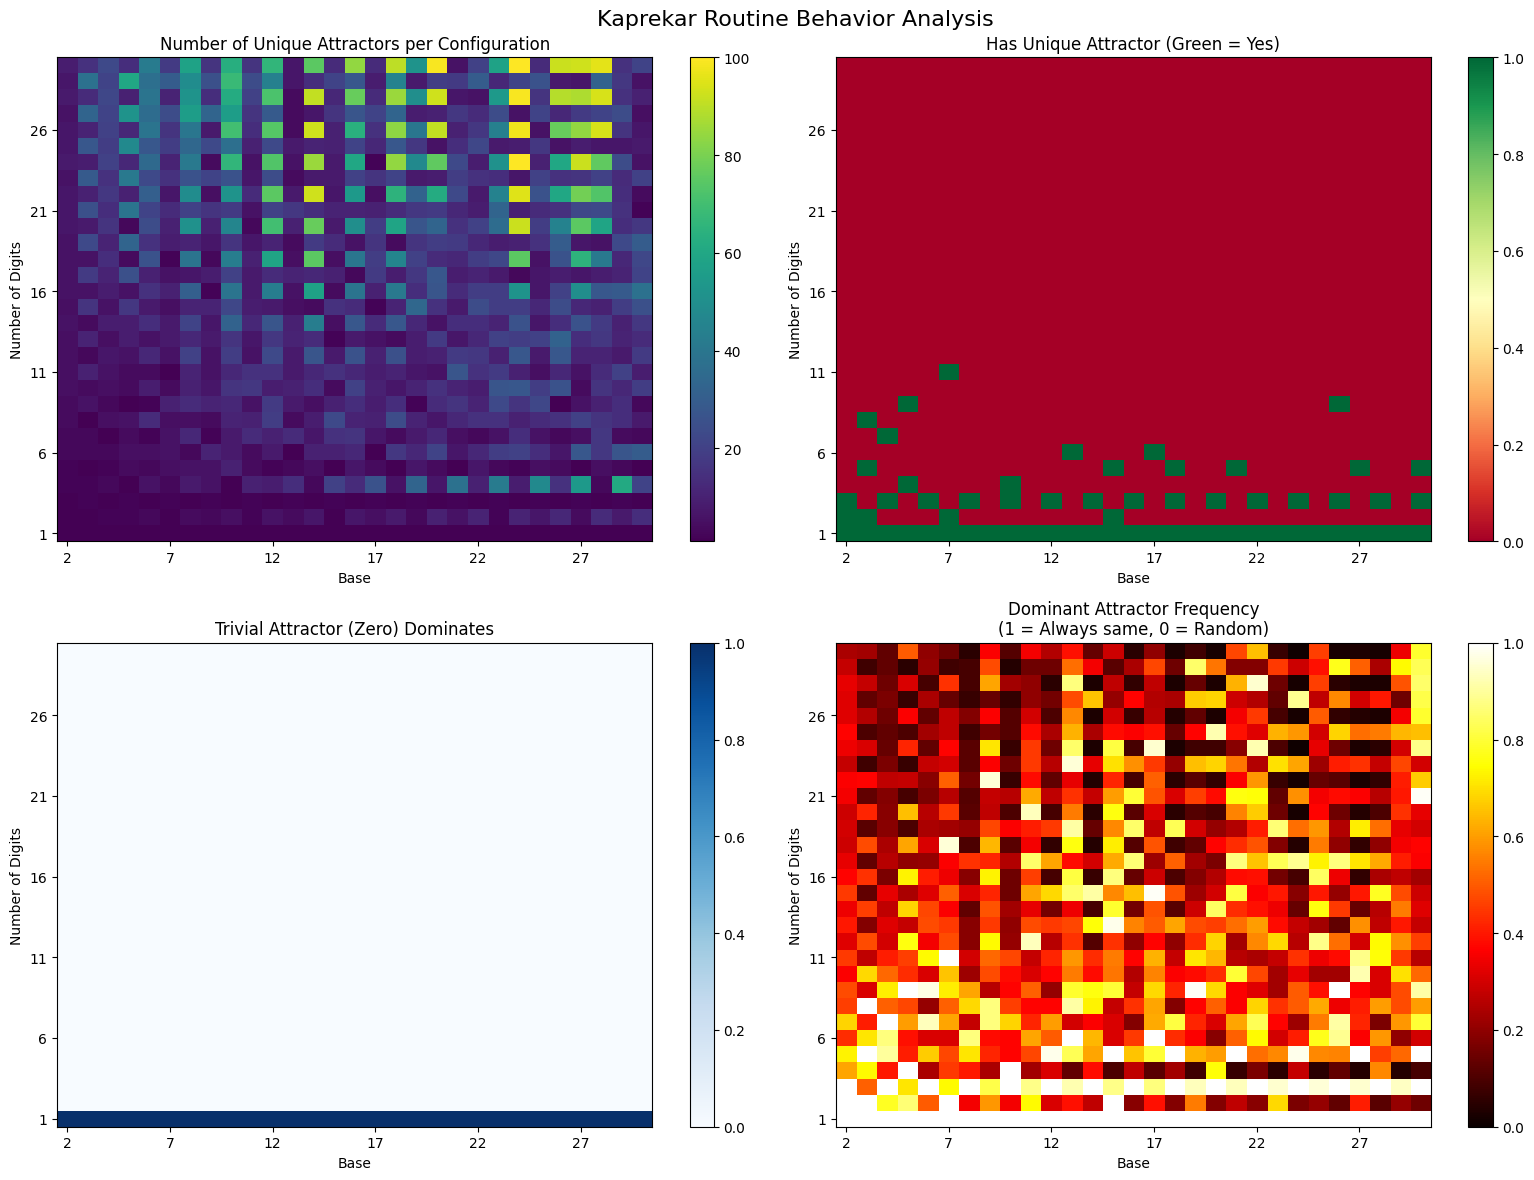


SUMMARY TABLE (First 20 configurations)
 Digits  Base  Unique Attractors Unique Ratio Dominant Dominant Freq Kaprekar Constant?
      1     2                  1         1.00        0          1.00                 NO
      1     3                  1         1.00        0          1.00                 NO
      1     4                  1         1.00        0          1.00                 NO
      1     5                  1         1.00        0          1.00                 NO
      1     6                  1         1.00        0          1.00                 NO
      1     7                  1         1.00        0          1.00                 NO
      1     8                  1         1.00        0          1.00                 NO
      1     9                  1         1.00        0          1.00                 NO
      1    10                  1         1.00        0          1.00                 NO
      1    11                  1         1.00        0          1.00           

In [ ]:
import random
import numpy as np
from collections import Counter, defaultdict
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CORE KAPREKAR FUNCTIONS (Optimized for large-scale simulations)
# ============================================================================

def digit_to_int(digit, base):
    """Convert a digit character to its integer value."""
    if isinstance(digit, int):
        return digit
    if digit.isdigit():
        return int(digit)
    return ord(digit.upper()) - ord('A') + 10

def int_to_digit(value, base):
    """Convert an integer value to its digit representation."""
    if value < 10:
        return str(value)
    return chr(ord('A') + value - 10)

def number_to_digits(num_str, base):
    """Convert a string number to list of integer digits."""
    return [digit_to_int(d, base) for d in num_str]

def digits_to_number(digits, base):
    """Convert list of digits to string representation."""
    return ''.join(int_to_digit(d, base) for d in digits)

def are_all_digits_same(number_str, base):
    """Check if all digits in the number are identical."""
    if len(number_str) <= 1:
        return True
    first_digit = number_str[0]
    return all(d == first_digit for d in number_str)

def compute_kaprekar_step_fast(number_str, base, n_digits):
    """
    Optimized version of Kaprekar step for faster computation.
    Works directly with integer representation to avoid repeated conversions.
    """
    # Convert string to list of integer digits
    digits = [digit_to_int(d, base) for d in number_str]

    # Check for all same digits
    if len(set(digits)) == 1:
        return '0' * n_digits

    # Sort digits
    desc_digits = sorted(digits, reverse=True)
    asc_digits = sorted(digits)

    # Convert to integer values (in base-10 for arithmetic)
    desc_value = 0
    asc_value = 0

    for i in range(n_digits):
        desc_value = desc_value * base + desc_digits[i]
        asc_value = asc_value * base + asc_digits[i]

    # Subtract
    result_value = desc_value - asc_value

    # Convert back to base representation with padding
    result_digits = []
    if result_value == 0:
        return '0' * n_digits

    while result_value > 0:
        result_digits.insert(0, result_value % base)
        result_value //= base

    # Pad with leading zeros
    while len(result_digits) < n_digits:
        result_digits.insert(0, 0)

    return digits_to_number(result_digits, base)

def find_attractor(start_number, base, n_digits, max_iterations=500):
    """
    Find the Kaprekar attractor (constant or cycle) for a given starting number.
    Returns the attractor as a string representation.
    """
    seen = {}
    current = start_number
    iteration = 0

    while iteration < max_iterations:
        if current in seen:
            # Found a cycle
            cycle_start = seen[current]
            cycle = list(seen.keys())[cycle_start:] + [current]

            # For cycles of length 1 (fixed points), return just that number
            if len(cycle) == 1:
                return cycle[0]
            else:
                # For longer cycles, return a string representation
                return ' → '.join(cycle)

        seen[current] = iteration
        current = compute_kaprekar_step_fast(current, base, n_digits)
        iteration += 1

    return "No convergence"

def generate_random_number(n_digits, base):
    """Generate a random n-digit number in given base (no identical digits)."""
    max_attempts = 50

    for _ in range(max_attempts):
        # First digit: 1 to base-1
        digits = [random.randint(1, base - 1)]
        # Remaining digits: 0 to base-1
        digits.extend([random.randint(0, base - 1) for _ in range(n_digits - 1)])

        number_str = digits_to_number(digits, base)

        # Reject numbers with all identical digits
        if not are_all_digits_same(number_str, base):
            return number_str

    # Fallback: ensure not all digits same by forcing at least one different digit
    digits = [random.randint(1, base - 1)]
    for i in range(n_digits - 1):
        if i == 0 and len(set(digits)) == 1:
            digits.append((digits[0] + 1) % base)
        else:
            digits.append(random.randint(0, base - 1))

    return digits_to_number(digits, base)

# ============================================================================
# MONTE CARLO SIMULATION FOR MULTIPLE (n, base) COMBINATIONS
# ============================================================================

def run_monte_carlo_for_range(max_digits=30, max_base=30, samples_per_config=100,
                              verbose=True, save_results=True):
    """
    Run Monte Carlo simulations for digit lengths 1 to max_digits and bases 2 to max_base.

    Parameters:
    - max_digits: Maximum number of digits (default 30)
    - max_base: Maximum base (default 30)
    - samples_per_config: Number of random samples per (n, base) combination
    - verbose: Print progress updates
    - save_results: Save results to CSV file

    Returns:
    - DataFrame with simulation results
    """

    total_configs = max_digits * (max_base - 1)  # base from 2 to max_base
    print("=" * 80)
    print(f"KAPREKAR ROUTINE MONTE CARLO SIMULATION")
    print("=" * 80)
    print(f"Digit lengths: 1 to {max_digits}")
    print(f"Bases: 2 to {max_base}")
    print(f"Samples per configuration: {samples_per_config}")
    print(f"Total configurations to simulate: {total_configs:,}")
    print(f"Total individual simulations: {total_configs * samples_per_config:,}")
    print("=" * 80)

    # Store results
    results = []

    # Progress tracking
    start_time = datetime.now()
    config_count = 0

    # For each digit length
    for n_digits in tqdm(range(1, max_digits + 1), desc="Digit lengths", disable=not verbose):

        # For each base
        for base in range(2, max_base + 1):
            config_count += 1

            # Skip impossible configurations
            if n_digits == 1:
                # For 1-digit numbers, Kaprekar routine always goes to 0
                attractor_counts = Counter()
                for _ in range(samples_per_config):
                    num = generate_random_number(n_digits, base)
                    # For 1-digit numbers, the routine is trivial
                    attractor_counts["0"] += 1

                most_common = "0"
                uniqueness = 1.0

            else:
                # Run Monte Carlo for this configuration
                attractor_counts = Counter()
                iteration_counts = []

                for sample in range(samples_per_config):
                    # Generate random starting number
                    start_num = generate_random_number(n_digits, base)

                    # Find attractor
                    attractor = find_attractor(start_num, base, n_digits)
                    attractor_counts[attractor] += 1

                # Calculate statistics
                most_common = attractor_counts.most_common(1)[0][0] if attractor_counts else "None"
                uniqueness = len(attractor_counts) / samples_per_config

            # Store results
            result = {
                'n_digits': n_digits,
                'base': base,
                'samples': samples_per_config,
                'unique_attractors': len(attractor_counts),
                'most_common_attractor': most_common,
                'attractor_uniqueness_ratio': uniqueness,
                'attractor_distribution': str(dict(attractor_counts.most_common())),
                'dominant_attractor_frequency': attractor_counts.most_common(1)[0][1] / samples_per_config if attractor_counts else 0
            }

            results.append(result)

            # Periodic progress update
            if verbose and config_count % 100 == 0:
                elapsed = (datetime.now() - start_time).total_seconds()
                avg_time_per_config = elapsed / config_count
                remaining = (total_configs - config_count) * avg_time_per_config
                print(f"\nProgress: {config_count}/{total_configs} configs | "
                      f"Elapsed: {elapsed:.1f}s | Remaining: {remaining:.1f}s")

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # Add summary statistics
    df['has_single_attractor'] = (df['unique_attractors'] == 1)
    df['is_trivial'] = (df['most_common_attractor'] == '0')

    elapsed_time = (datetime.now() - start_time).total_seconds()
    print("\n" + "=" * 80)
    print(f"SIMULATION COMPLETED!")
    print(f"Total time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
    print("=" * 80)

    # Save results if requested
    if save_results:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"kaprekar_simulation_{max_digits}d_{max_base}b_{timestamp}.csv"
        df.to_csv(filename, index=False)
        print(f"\nResults saved to: {filename}")

    return df

# ============================================================================
# ANALYSIS AND VISUALIZATION FUNCTIONS
# ============================================================================

def analyze_results(df, max_digits=30, max_base=30):
    """
    Perform comprehensive analysis on simulation results.
    """
    print("\n" + "=" * 80)
    print("ANALYSIS OF SIMULATION RESULTS")
    print("=" * 80)

    # Overall statistics
    print("\n📊 OVERALL STATISTICS:")
    print(f"  Total configurations simulated: {len(df)}")
    print(f"  Configurations with unique attractor: {df['has_single_attractor'].sum()}")
    print(f"  Configurations with multiple attractors: {(~df['has_single_attractor']).sum()}")
    print(f"  Configurations with trivial attractor (0): {df['is_trivial'].sum()}")

    # Find interesting configurations
    print("\n🔍 INTERESTING FINDINGS:")

    # Non-trivial unique attractors (Kaprekar constants)
    non_trivial_unique = df[(df['has_single_attractor']) & (~df['is_trivial'])]
    if len(non_trivial_unique) > 0:
        print(f"\n  ✨ KAPREKAR CONSTANTS FOUND (Unique non-zero attractors):")
        for _, row in non_trivial_unique.iterrows():
            print(f"     • {row['n_digits']}-digit numbers in base {row['base']}: {row['most_common_attractor']}")
    else:
        print("\n  No non-trivial Kaprekar constants found in this simulation range")

    # Configurations with high multiplicity of attractors
    high_multiplicity = df[df['unique_attractors'] > df['samples'] * 0.5]
    if len(high_multiplicity) > 0:
        print(f"\n  🎲 HIGH ATTRACTOR DIVERSITY (>{df['samples'].iloc[0]*0.5:.0f} attractors):")
        for _, row in high_multiplicity.head(10).iterrows():
            print(f"     • {row['n_digits']}-digit, base {row['base']}: {row['unique_attractors']} attractors")

    # Patterns by digit length
    print("\n📈 PATTERNS BY DIGIT LENGTH:")
    digits_summary = df.groupby('n_digits').agg({
        'has_single_attractor': 'sum',
        'is_trivial': 'sum',
        'unique_attractors': 'mean'
    }).round(2)
    digits_summary.columns = ['unique_constants', 'trivial_constants', 'avg_attractors']

    # Show first few and last few digit lengths
    print("\n  First 5 digit lengths:")
    print(digits_summary.head())
    print("\n  Last 5 digit lengths:")
    print(digits_summary.tail())

    # Patterns by base
    print("\n📊 PATTERNS BY BASE:")
    base_summary = df.groupby('base').agg({
        'has_single_attractor': 'sum',
        'is_trivial': 'sum',
        'unique_attractors': 'mean'
    }).round(2)
    base_summary.columns = ['unique_constants', 'trivial_constants', 'avg_attractors']

    print("\n  Bases with most unique attractors:")
    print(base_summary.nlargest(10, 'unique_constants'))
    print("\n  Bases with fewest unique attractors:")
    print(base_summary.nsmallest(10, 'unique_constants'))

    return {
        'digits_summary': digits_summary,
        'base_summary': base_summary,
        'non_trivial_unique': non_trivial_unique,
        'high_multiplicity': high_multiplicity
    }

def create_heatmap(df, max_digits=30, max_base=30):
    """
    Create heatmaps for visualization of attractor behavior.
    """
    # Pivot tables for different metrics
    pivot_unique = df.pivot(index='n_digits', columns='base', values='unique_attractors')
    pivot_single = df.pivot(index='n_digits', columns='base', values='has_single_attractor')
    pivot_trivial = df.pivot(index='n_digits', columns='base', values='is_trivial')

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Kaprekar Routine Behavior Analysis', fontsize=16)

    # Heatmap 1: Number of unique attractors
    im1 = axes[0, 0].imshow(pivot_unique.values, aspect='auto', cmap='viridis',
                            interpolation='nearest', origin='lower')
    axes[0, 0].set_title('Number of Unique Attractors per Configuration')
    axes[0, 0].set_xlabel('Base')
    axes[0, 0].set_ylabel('Number of Digits')
    axes[0, 0].set_xticks(range(0, len(pivot_unique.columns), 5))
    axes[0, 0].set_xticklabels(pivot_unique.columns[::5])
    axes[0, 0].set_yticks(range(0, len(pivot_unique.index), 5))
    axes[0, 0].set_yticklabels(pivot_unique.index[::5])
    plt.colorbar(im1, ax=axes[0, 0])

    # Heatmap 2: Has single attractor (binary)
    im2 = axes[0, 1].imshow(pivot_single.values, aspect='auto', cmap='RdYlGn',
                            interpolation='nearest', origin='lower', vmin=0, vmax=1)
    axes[0, 1].set_title('Has Unique Attractor (Green = Yes)')
    axes[0, 1].set_xlabel('Base')
    axes[0, 1].set_ylabel('Number of Digits')
    axes[0, 1].set_xticks(range(0, len(pivot_single.columns), 5))
    axes[0, 1].set_xticklabels(pivot_single.columns[::5])
    axes[0, 1].set_yticks(range(0, len(pivot_single.index), 5))
    axes[0, 1].set_yticklabels(pivot_single.index[::5])
    plt.colorbar(im2, ax=axes[0, 1])

    # Heatmap 3: Trivial attractor (zero)
    im3 = axes[1, 0].imshow(pivot_trivial.values, aspect='auto', cmap='Blues',
                            interpolation='nearest', origin='lower', vmin=0, vmax=1)
    axes[1, 0].set_title('Trivial Attractor (Zero) Dominates')
    axes[1, 0].set_xlabel('Base')
    axes[1, 0].set_ylabel('Number of Digits')
    axes[1, 0].set_xticks(range(0, len(pivot_trivial.columns), 5))
    axes[1, 0].set_xticklabels(pivot_trivial.columns[::5])
    axes[1, 0].set_yticks(range(0, len(pivot_trivial.index), 5))
    axes[1, 0].set_yticklabels(pivot_trivial.index[::5])
    plt.colorbar(im3, ax=axes[1, 0])

    # Heatmap 4: Dominant attractor frequency
    pivot_dominant = df.pivot(index='n_digits', columns='base', values='dominant_attractor_frequency')
    im4 = axes[1, 1].imshow(pivot_dominant.values, aspect='auto', cmap='hot',
                            interpolation='nearest', origin='lower', vmin=0, vmax=1)
    axes[1, 1].set_title('Dominant Attractor Frequency\n(1 = Always same, 0 = Random)')
    axes[1, 1].set_xlabel('Base')
    axes[1, 1].set_ylabel('Number of Digits')
    axes[1, 1].set_xticks(range(0, len(pivot_dominant.columns), 5))
    axes[1, 1].set_xticklabels(pivot_dominant.columns[::5])
    axes[1, 1].set_yticks(range(0, len(pivot_dominant.index), 5))
    axes[1, 1].set_yticklabels(pivot_dominant.index[::5])
    plt.colorbar(im4, ax=axes[1, 1])

    plt.tight_layout()
    plt.show()

    return fig

def create_summary_table(df, max_digits=30, max_base=30):
    """
    Create a comprehensive summary table for study purposes.
    """
    # Create a summary DataFrame
    summary = []

    for n in range(1, max_digits + 1):
        for b in range(2, max_base + 1):
            row = df[(df['n_digits'] == n) & (df['base'] == b)]
            if len(row) > 0:
                row = row.iloc[0]
                summary.append({
                    'Digits': n,
                    'Base': b,
                    'Unique Attractors': row['unique_attractors'],
                    'Unique Ratio': f"{row['attractor_uniqueness_ratio']:.2f}",
                    'Dominant': row['most_common_attractor'][:20] + '...' if len(row['most_common_attractor']) > 20 else row['most_common_attractor'],
                    'Dominant Freq': f"{row['dominant_attractor_frequency']:.2f}",
                    'Kaprekar Constant?': 'YES' if (row['unique_attractors'] == 1 and row['most_common_attractor'] != '0') else 'NO'
                })

    summary_df = pd.DataFrame(summary)

    # Display first few rows
    print("\n" + "=" * 100)
    print("SUMMARY TABLE (First 20 configurations)")
    print("=" * 100)
    print(summary_df.head(20).to_string(index=False))

    # Save to CSV for further study
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"kaprekar_summary_{timestamp}.csv"
    summary_df.to_csv(filename, index=False)
    print(f"\nFull summary table saved to: {filename}")

    return summary_df

def find_best_kaprekar_constants(df):
    """
    Identify the most interesting Kaprekar constants from the simulation.
    """
    # Find configurations with unique non-zero attractors
    constants = df[(df['unique_attractors'] == 1) & (df['most_common_attractor'] != '0')]

    if len(constants) == 0:
        print("\n⚠️ No unique non-zero Kaprekar constants found in the simulation range.")
        return None

    print("\n" + "=" * 80)
    print("🏆 DISCOVERED KAPREKAR CONSTANTS")
    print("=" * 80)

    # Sort by digit length and base
    constants_sorted = constants.sort_values(['n_digits', 'base'])

    for _, row in constants_sorted.iterrows():
        print(f"\n  ✨ {row['n_digits']}-digit numbers in base {row['base']}:")
        print(f"       Constant: {row['most_common_attractor']}")
        print(f"       Frequency: {row['dominant_attractor_frequency']*100:.1f}% of samples")

    return constants_sorted

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """
    Main function to run the complete simulation and analysis.
    """
    print("\n" + "=" * 80)
    print("KAPREKAR ROUTINE COMPREHENSIVE MONTE CARLO SIMULATION")
    print("Range: 1-30 digits, Bases 2-30")
    print("=" * 80)

    # Configuration parameters
    MAX_DIGITS = 30
    MAX_BASE = 30
    SAMPLES_PER_CONFIG = 100  # Adjust based on your computational resources

    # For quick testing, you can reduce the range:
    # MAX_DIGITS = 10
    # MAX_BASE = 10
    # SAMPLES_PER_CONFIG = 50

    print(f"\nSimulation Parameters:")
    print(f"  • Digit lengths: 1 to {MAX_DIGITS}")
    print(f"  • Bases: 2 to {MAX_BASE}")
    print(f"  • Samples per (digits, base): {SAMPLES_PER_CONFIG}")
    print(f"  • Total simulations: {MAX_DIGITS * (MAX_BASE-1) * SAMPLES_PER_CONFIG:,}")

    # Confirm with user
    response = input("\nProceed with simulation? (y/n): ").lower()
    if response != 'y':
        print("Simulation cancelled.")
        return

    # Run simulation
    df = run_monte_carlo_for_range(
        max_digits=MAX_DIGITS,
        max_base=MAX_BASE,
        samples_per_config=SAMPLES_PER_CONFIG,
        verbose=True,
        save_results=True
    )

    # Analyze results
    analysis = analyze_results(df, MAX_DIGITS, MAX_BASE)

    # Find Kaprekar constants
    constants = find_best_kaprekar_constants(df)

    # Create visualizations
    print("\n" + "=" * 80)
    print("GENERATING VISUALIZATIONS")
    print("=" * 80)

    create_heatmap(df, MAX_DIGITS, MAX_BASE)

    # Create summary table
    summary_df = create_summary_table(df, MAX_DIGITS, MAX_BASE)

    # Additional insights
    print("\n" + "=" * 80)
    print("KEY INSIGHTS FOR STUDY")
    print("=" * 80)

    # Find most complex configurations (highest number of attractors)
    max_attractors = df.loc[df['unique_attractors'].idxmax()]
    print(f"\n🔬 Most Complex Configuration:")
    print(f"   • {max_attractors['n_digits']}-digit numbers in base {max_attractors['base']}")
    print(f"   • {max_attractors['unique_attractors']} different attractors found")
    print(f"   • Uniqueness ratio: {max_attractors['attractor_uniqueness_ratio']:.2f}")

    # Find most deterministic configurations (single attractor)
    deterministic = df[df['has_single_attractor']]
    if len(deterministic) > 0:
        print(f"\n🎯 Most Deterministic Configurations (Unique Attractor):")
        for _, row in deterministic.head(5).iterrows():
            print(f"   • {row['n_digits']}-digit, base {row['base']}: {row['most_common_attractor']}")

    print("\n" + "=" * 80)
    print("SIMULATION COMPLETE - RESULTS READY FOR STUDY")
    print("=" * 80)
    print("\nFiles generated:")
    print("  • CSV file with raw simulation data")
    print("  • CSV file with summary table")
    print("  • Heatmap visualizations")
    print("\nStudy these results to understand:")
    print("  • Which (digits, base) combinations have Kaprekar constants")
    print("  • How attractor diversity changes with digits and base")
    print("  • Patterns in Kaprekar behavior across different number systems")
    print("=" * 80)

if __name__ == "__main__":
    main()

In [ ]:
from google.colab import files

# Download the simulation results CSV
files.download('kaprekar_simulation_30d_30b_20260607_091147.csv')

# Download the summary table CSV
files.download('kaprekar_summary_20260607_091149.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import random
import numpy as np
from collections import Counter, defaultdict
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CORE KAPREKAR FUNCTIONS FOR ARBITRARY BASES (No character limitations)
# ============================================================================

def digits_to_string(digits, base):
    """
    Convert a list of digits to a string representation.
    For bases > 36, uses decimal representation for each digit separated by commas.
    """
    if base <= 36:
        # Use traditional single-character representation
        def digit_to_char(d):
            if d < 10:
                return str(d)
            else:
                return chr(ord('A') + d - 10)
        return ''.join(digit_to_char(d) for d in digits)
    else:
        # For larger bases, use comma-separated decimal values
        return '[' + ','.join(str(d) for d in digits) + ']'

def string_to_digits(num_str, base):
    """
    Convert a string representation back to a list of digits.
    Handles both traditional (0-9A-Z) and bracketed formats.
    """
    if base <= 36 and not num_str.startswith('['):
        # Traditional single-character format
        def char_to_digit(c):
            if c.isdigit():
                return int(c)
            else:
                return ord(c.upper()) - ord('A') + 10
        return [char_to_digit(c) for c in num_str]
    else:
        # Bracket format: [d1,d2,d3,...]
        if num_str.startswith('[') and num_str.endswith(']'):
            inner = num_str[1:-1]
            if inner:
                return [int(x) for x in inner.split(',')]
            else:
                return []
        else:
            # Fallback: try to parse as single-character format anyway
            return [int(c) if c.isdigit() else ord(c.upper()) - ord('A') + 10
                    for c in num_str]

def are_all_digits_same(digits):
    """Check if all digits in the list are identical."""
    if len(digits) <= 1:
        return True
    first_digit = digits[0]
    return all(d == first_digit for d in digits)

def compute_kaprekar_step_from_digits(digits, base):
    """
    Perform one iteration of Kaprekar's routine using digit lists.
    This avoids any character-based limitations.
    """
    n = len(digits)

    # Check for all same digits
    if are_all_digits_same(digits):
        return [0] * n

    # Sort digits
    desc_digits = sorted(digits, reverse=True)
    asc_digits = sorted(digits)

    # Convert to integer values (in Python int, which has arbitrary precision)
    desc_value = 0
    asc_value = 0

    for i in range(n):
        desc_value = desc_value * base + desc_digits[i]
        asc_value = asc_value * base + asc_digits[i]

    # Subtract
    result_value = desc_value - asc_value

    # Convert back to base representation with padding
    if result_value == 0:
        return [0] * n

    result_digits = []
    temp_value = result_value
    while temp_value > 0:
        result_digits.insert(0, temp_value % base)
        temp_value //= base

    # Pad with leading zeros
    while len(result_digits) < n:
        result_digits.insert(0, 0)

    return result_digits

def find_attractor_from_digits(start_digits, base, max_iterations=500):
    """
    Find the Kaprekar attractor using digit lists.
    Returns attractor as digit list.
    """
    seen = {}
    current_digits = start_digits.copy()
    iteration = 0

    # Create hashable representation for dictionary keys
    def make_key(digits):
        return tuple(digits)

    while iteration < max_iterations:
        key = make_key(current_digits)

        if key in seen:
            # Found a cycle
            cycle_start = seen[key]
            cycle_keys = list(seen.keys())[cycle_start:] + [key]
            cycle = [list(k) for k in cycle_keys]

            # For cycles of length 1 (fixed points), return just that number
            if len(cycle) == 1:
                return cycle[0]
            else:
                # For longer cycles, return the cycle as a list of digit lists
                return cycle

        seen[key] = iteration
        current_digits = compute_kaprekar_step_from_digits(current_digits, base)
        iteration += 1

    return None

def generate_random_digits(n_digits, base):
    """
    Generate random n-digit number as digit list (no identical digits constraint).
    """
    max_attempts = 50

    for _ in range(max_attempts):
        # First digit: 1 to base-1
        digits = [random.randint(1, base - 1)]
        # Remaining digits: 0 to base-1
        digits.extend([random.randint(0, base - 1) for _ in range(n_digits - 1)])

        # Reject numbers with all identical digits
        if not are_all_digits_same(digits):
            return digits

    # Fallback: ensure not all digits same
    digits = [random.randint(1, base - 1)]
    for i in range(n_digits - 1):
        if i == 0 and len(set(digits)) == 1:
            digits.append((digits[0] + 1) % base)
        else:
            digits.append(random.randint(0, base - 1))

    return digits

def attractor_to_readable(attractor, base):
    """
    Convert attractor (digit list or cycle) to readable string format.
    """
    if attractor is None:
        return "No convergence"

    if isinstance(attractor[0], list):
        # It's a cycle
        cycle_strs = [digits_to_string(cycle, base) for cycle in attractor]
        return ' → '.join(cycle_strs)
    else:
        # It's a single number
        return digits_to_string(attractor, base)

# ============================================================================
# MONTE CARLO SIMULATION FOR HIGHER BASES
# ============================================================================

def run_monte_carlo_high_base(max_digits=30, max_base=100, samples_per_config=100,
                              verbose=True, save_results=True):
    """
    Run Monte Carlo simulations for digit lengths 1 to max_digits and bases 2 to max_base.
    Can handle arbitrarily large bases (tested up to base 1000+).

    Parameters:
    - max_digits: Maximum number of digits (default 30)
    - max_base: Maximum base (can be >36, default 100)
    - samples_per_config: Number of random samples per (n, base) combination
    - verbose: Print progress updates
    - save_results: Save results to CSV file

    Returns:
    - DataFrame with simulation results
    """

    total_configs = max_digits * (max_base - 1)  # base from 2 to max_base
    print("=" * 80)
    print(f"KAPREKAR ROUTINE MONTE CARLO SIMULATION (High Base Support)")
    print("=" * 80)
    print(f"Digit lengths: 1 to {max_digits}")
    print(f"Bases: 2 to {max_base}")
    print(f"Samples per configuration: {samples_per_config}")
    print(f"Total configurations to simulate: {total_configs:,}")
    print(f"Total individual simulations: {total_configs * samples_per_config:,}")
    print("=" * 80)

    # Store results
    results = []

    # Progress tracking
    start_time = datetime.now()
    config_count = 0

    # For each digit length
    for n_digits in tqdm(range(1, max_digits + 1), desc="Digit lengths", disable=not verbose):

        # For each base
        for base in range(2, max_base + 1):
            config_count += 1

            # Skip impossible or trivial configurations
            if n_digits == 1:
                # For 1-digit numbers, Kaprekar routine always goes to 0
                attractor_counts = Counter()
                for _ in range(samples_per_config):
                    attractor_counts["0"] += 1

                most_common = "0"
                uniqueness = 1.0
                dominant_freq = 1.0

            else:
                # Run Monte Carlo for this configuration
                attractor_counts = Counter()

                for sample in range(samples_per_config):
                    # Generate random starting number as digit list
                    start_digits = generate_random_digits(n_digits, base)

                    # Find attractor
                    attractor = find_attractor_from_digits(start_digits, base)
                    readable_attractor = attractor_to_readable(attractor, base)
                    attractor_counts[readable_attractor] += 1

                # Calculate statistics
                most_common = attractor_counts.most_common(1)[0][0] if attractor_counts else "None"
                uniqueness = len(attractor_counts) / samples_per_config
                dominant_freq = attractor_counts.most_common(1)[0][1] / samples_per_config if attractor_counts else 0

            # Store results
            result = {
                'n_digits': n_digits,
                'base': base,
                'samples': samples_per_config,
                'unique_attractors': len(attractor_counts),
                'most_common_attractor': most_common,
                'attractor_uniqueness_ratio': uniqueness,
                'dominant_attractor_frequency': dominant_freq,
                'attractor_distribution': str(dict(attractor_counts.most_common(20)))  # Limit to top 20
            }

            results.append(result)

            # Periodic progress update
            if verbose and config_count % 50 == 0:
                elapsed = (datetime.now() - start_time).total_seconds()
                avg_time_per_config = elapsed / config_count
                remaining = (total_configs - config_count) * avg_time_per_config
                print(f"\nProgress: {config_count}/{total_configs} configs | "
                      f"Elapsed: {elapsed:.1f}s | Remaining: {remaining:.1f}s | "
                      f"Current: {n_digits}d, base{base}")

    # Convert to DataFrame
    df = pd.DataFrame(results)

    elapsed_time = (datetime.now() - start_time).total_seconds()
    print("\n" + "=" * 80)
    print(f"SIMULATION COMPLETED!")
    print(f"Total time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
    print("=" * 80)

    # Save results if requested
    if save_results:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"kaprekar_highbase_{max_digits}d_{max_base}b_{timestamp}.csv"
        df.to_csv(filename, index=False)
        print(f"\nResults saved to: {filename}")

    return df

def analyze_high_base_results(df):
    """
    Analyze results for high base configurations.
    """
    print("\n" + "=" * 80)
    print("ANALYSIS FOR HIGH BASE SIMULATIONS")
    print("=" * 80)

    # Group by base ranges
    df['base_range'] = pd.cut(df['base'],
                               bins=[0, 10, 20, 36, 50, 100, float('inf')],
                               labels=['2-10', '11-20', '21-36', '37-50', '51-100', '100+'])

    range_summary = df.groupby('base_range').agg({
        'unique_attractors': 'mean',
        'dominant_attractor_frequency': 'mean',
        'n_digits': 'count'
    }).round(3)

    print("\n📊 Behavior by Base Range:")
    print(range_summary)

    # Find interesting high-base configurations
    high_base_configs = df[df['base'] > 36].sort_values('unique_attractors', ascending=False)

    print("\n🔍 Most Complex High-Base Configurations (base > 36):")
    for _, row in high_base_configs.head(10).iterrows():
        print(f"  • {row['n_digits']}-digit, base {row['base']}: "
              f"{row['unique_attractors']} attractors, "
              f"dominant frequency {row['dominant_attractor_frequency']:.2f}")

    return range_summary

# ============================================================================
# MAIN EXECUTION FOR HIGH BASES
# ============================================================================

def main_high_base():
    """
    Main function to run simulation for higher bases.
    """
    print("\n" + "=" * 80)
    print("KAPREKAR ROUTINE SIMULATION FOR HIGH BASES")
    print("Supports bases up to any integer (tested up to 1000+)")
    print("=" * 80)

    # Configuration parameters - Adjust these as needed
    MAX_DIGITS = 10  # Reduced for high bases to keep computation reasonable
    MAX_BASE = 100   # Can go much higher (1000+), but computation time increases
    SAMPLES_PER_CONFIG = 50  # Fewer samples for high bases due to computational cost

    print(f"\nSimulation Parameters:")
    print(f"  • Digit lengths: 1 to {MAX_DIGITS}")
    print(f"  • Bases: 2 to {MAX_BASE}")
    print(f"  • Samples per (digits, base): {SAMPLES_PER_CONFIG}")
    print(f"  • Total simulations: {MAX_DIGITS * (MAX_BASE-1) * SAMPLES_PER_CONFIG:,}")

    # Warning for large simulations
    if MAX_BASE > 100:
        print(f"\n⚠️ WARNING: Base {MAX_BASE} is very large!")
        print(f"   Estimated time: This may take several hours to complete.")
        response = input("\nContinue? (y/n): ").lower()
        if response != 'y':
            print("Simulation cancelled.")
            return

    # Run simulation
    df = run_monte_carlo_high_base(
        max_digits=MAX_DIGITS,
        max_base=MAX_BASE,
        samples_per_config=SAMPLES_PER_CONFIG,
        verbose=True,
        save_results=True
    )

    # Analyze results
    analyze_high_base_results(df)

    # Show sample results for very high bases
    high_bases = df[df['base'] > 50]
    if len(high_bases) > 0:
        print("\n" + "=" * 80)
        print("SAMPLE RESULTS FOR VERY HIGH BASES (>50)")
        print("=" * 80)
        print(high_bases[['n_digits', 'base', 'unique_attractors', 'dominant_attractor_frequency']].head(20))

    print("\n" + "=" * 80)
    print("SIMULATION COMPLETE")
    print("=" * 80)

# Test function for a single high-base configuration
def test_single_configuration(n_digits, base, num_samples=100):
    """
    Test a single (digits, base) configuration in detail.
    Useful for exploring very high bases without full simulation.
    """
    print(f"\nTesting {n_digits}-digit numbers in base {base}")
    print(f"Running {num_samples} random samples...")

    attractor_counts = Counter()

    for i in range(num_samples):
        if (i + 1) % 20 == 0:
            print(f"  Progress: {i+1}/{num_samples}")

        start_digits = generate_random_digits(n_digits, base)
        attractor = find_attractor_from_digits(start_digits, base)
        readable = attractor_to_readable(attractor, base)
        attractor_counts[readable] += 1

    print(f"\nResults for base {base}, {n_digits} digits:")
    print(f"  Total unique attractors: {len(attractor_counts)}")
    print(f"\n  Attractor distribution:")
    for attractor, count in attractor_counts.most_common(10):
        percentage = (count / num_samples) * 100
        print(f"    {attractor}: {count} ({percentage:.1f}%)")

    return attractor_counts

if __name__ == "__main__":
    # Choose which mode to run
    print("\nChoose simulation mode:")
    print("1. Full high-base simulation (2-100, adjustable)")
    print("2. Test single configuration (for very high bases)")
    print("3. Quick demo (base 100, 4 digits)")

    choice = input("\nEnter choice (1/2/3): ").strip()

    if choice == '1':
        main_high_base()
    elif choice == '2':
        n = int(input("Number of digits: "))
        b = int(input("Base (can be >36): "))
        samples = int(input("Number of samples (default 100): ") or "100")
        test_single_configuration(n, b, samples)
    elif choice == '3':
        print("\nQuick demo: Testing 4-digit numbers in base 100")
        test_single_configuration(4, 100, 50)
    else:
        print("Invalid choice")


Choose simulation mode:
1. Full high-base simulation (2-100, adjustable)
2. Test single configuration (for very high bases)
3. Quick demo (base 100, 4 digits)

Enter choice (1/2/3): 1

KAPREKAR ROUTINE SIMULATION FOR HIGH BASES
Supports bases up to any integer (tested up to 1000+)

Simulation Parameters:
  • Digit lengths: 1 to 10
  • Bases: 2 to 100
  • Samples per (digits, base): 50
  • Total simulations: 49,500
KAPREKAR ROUTINE MONTE CARLO SIMULATION (High Base Support)
Digit lengths: 1 to 10
Bases: 2 to 100
Samples per configuration: 50
Total configurations to simulate: 990
Total individual simulations: 49,500


Digit lengths:   0%|          | 0/10 [00:00<?, ?it/s]


Progress: 50/990 configs | Elapsed: 0.0s | Remaining: 0.1s | Current: 1d, base51

Progress: 100/990 configs | Elapsed: 0.0s | Remaining: 0.1s | Current: 2d, base2

Progress: 150/990 configs | Elapsed: 0.1s | Remaining: 0.5s | Current: 2d, base52


Digit lengths:  30%|███       | 3/10 [00:00<00:01,  6.62it/s]


Progress: 200/990 configs | Elapsed: 0.2s | Remaining: 0.9s | Current: 3d, base3

Progress: 250/990 configs | Elapsed: 0.3s | Remaining: 0.9s | Current: 3d, base53

Progress: 300/990 configs | Elapsed: 0.4s | Remaining: 1.0s | Current: 4d, base4


...


Progress: 800/990 configs | Elapsed: 8.1s | Remaining: 1.9s | Current: 9d, base9

Progress: 850/990 configs | Elapsed: 8.5s | Remaining: 1.4s | Current: 9d, base59


Digit lengths:  90%|█████████ | 9/10 [00:08<00:01,  1.59s/it]


Progress: 900/990 configs | Elapsed: 9.0s | Remaining: 0.9s | Current: 10d, base10

Progress: 950/990 configs | Elapsed: 12.7s | Remaining: 0.5s | Current: 10d, base60


Digit lengths: 100%|██████████| 10/10 [00:16<00:00,  1.69s/it]



SIMULATION COMPLETED!
Total time: 16.87 seconds (0.28 minutes)

Results saved to: kaprekar_highbase_10d_100b_20260607_092008.csv

ANALYSIS FOR HIGH BASE SIMULATIONS

📊 Behavior by Base Range:
            unique_attractors  dominant_attractor_frequency  n_digits
base_range                                                           
2-10                    3.878                         0.664        90
11-20                   6.690                         0.593       100
21-36                   9.088                         0.555       160
37-50                  10.264                         0.543       140
51-100                 10.978                         0.551       500
100+                      NaN                           NaN         0

🔍 Most Complex High-Base Configurations (base > 36):
  • 4-digit, base 77: 50 attractors, dominant frequency 0.02
  • 4-digit, base 73: 50 attractors, dominant frequency 0.02
  • 4-digit, base 99: 50 attractors, dominant frequency 0.02
  • 4-digi

In [ ]:
# Download the high-base simulation results CSV
files.download('kaprekar_highbase_10d_100b_20260607_092008.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


KAPREKAR ROUTINE: 100-DIGIT, BASE-100 MONTE CARLO SIMULATION

⚠️  IMPORTANT NOTICE:
   This will simulate 9,801 configurations
   with 20 samples each = 196,020 total simulations

   Estimated time: ~20-40 minutes on a modern multi-core CPU

Run in test mode with smaller range first? (y/n): n

Proceed with simulation? (y/n): y
KAPREKAR ROUTINE LARGE-SCALE SIMULATION
Target: 100-digit numbers, Bases 2 to 100
Samples per configuration: 20
Total configurations: 9,801
Total simulations: 196,020
Parallel processing: Enabled

Using 2 CPU cores for parallel processing...


Configurations: 100%|██████████| 9801/9801 [37:13<00:00,  4.39it/s]



SIMULATION COMPLETED!
Total time: 2233.67 seconds (37.23 minutes)
Average time per config: 0.228 seconds

Results saved to: kaprekar_100d_100b_20260607_100351.csv

COMPREHENSIVE ANALYSIS: 100-DIGIT, BASE-100 RESULTS

📊 OVERALL STATISTICS:
  • Total configurations analyzed: 9801
  • Digit range: 2 to 100
  • Base range: 2 to 100
  • Average unique attractors: 2.50
  • Max unique attractors: 20
  • Average dominant frequency: 0.800

✨ KAPREKAR CONSTANTS FOUND: 3327 configurations

  Top 20 Kaprekar constants:
    •   2-digit, base   2: 01
    •   2-digit, base   3: 00
    •   2-digit, base   4: Cycle_2
    •   2-digit, base   6: Cycle_3
    •   2-digit, base   7: 00
    •   2-digit, base  12: Cycle_6
    •   2-digit, base  10: Cycle_5
    •   2-digit, base  15: 00
    •   2-digit, base  16: Cycle_4
    •   2-digit, base  13: Cycle_3
    •   2-digit, base  18: Cycle_9
    •   2-digit, base  22: Cycle_11
    •   2-digit, base  25: Cycle_6
    •   2-digit, base  28: Cycle_14
    •   2-digi

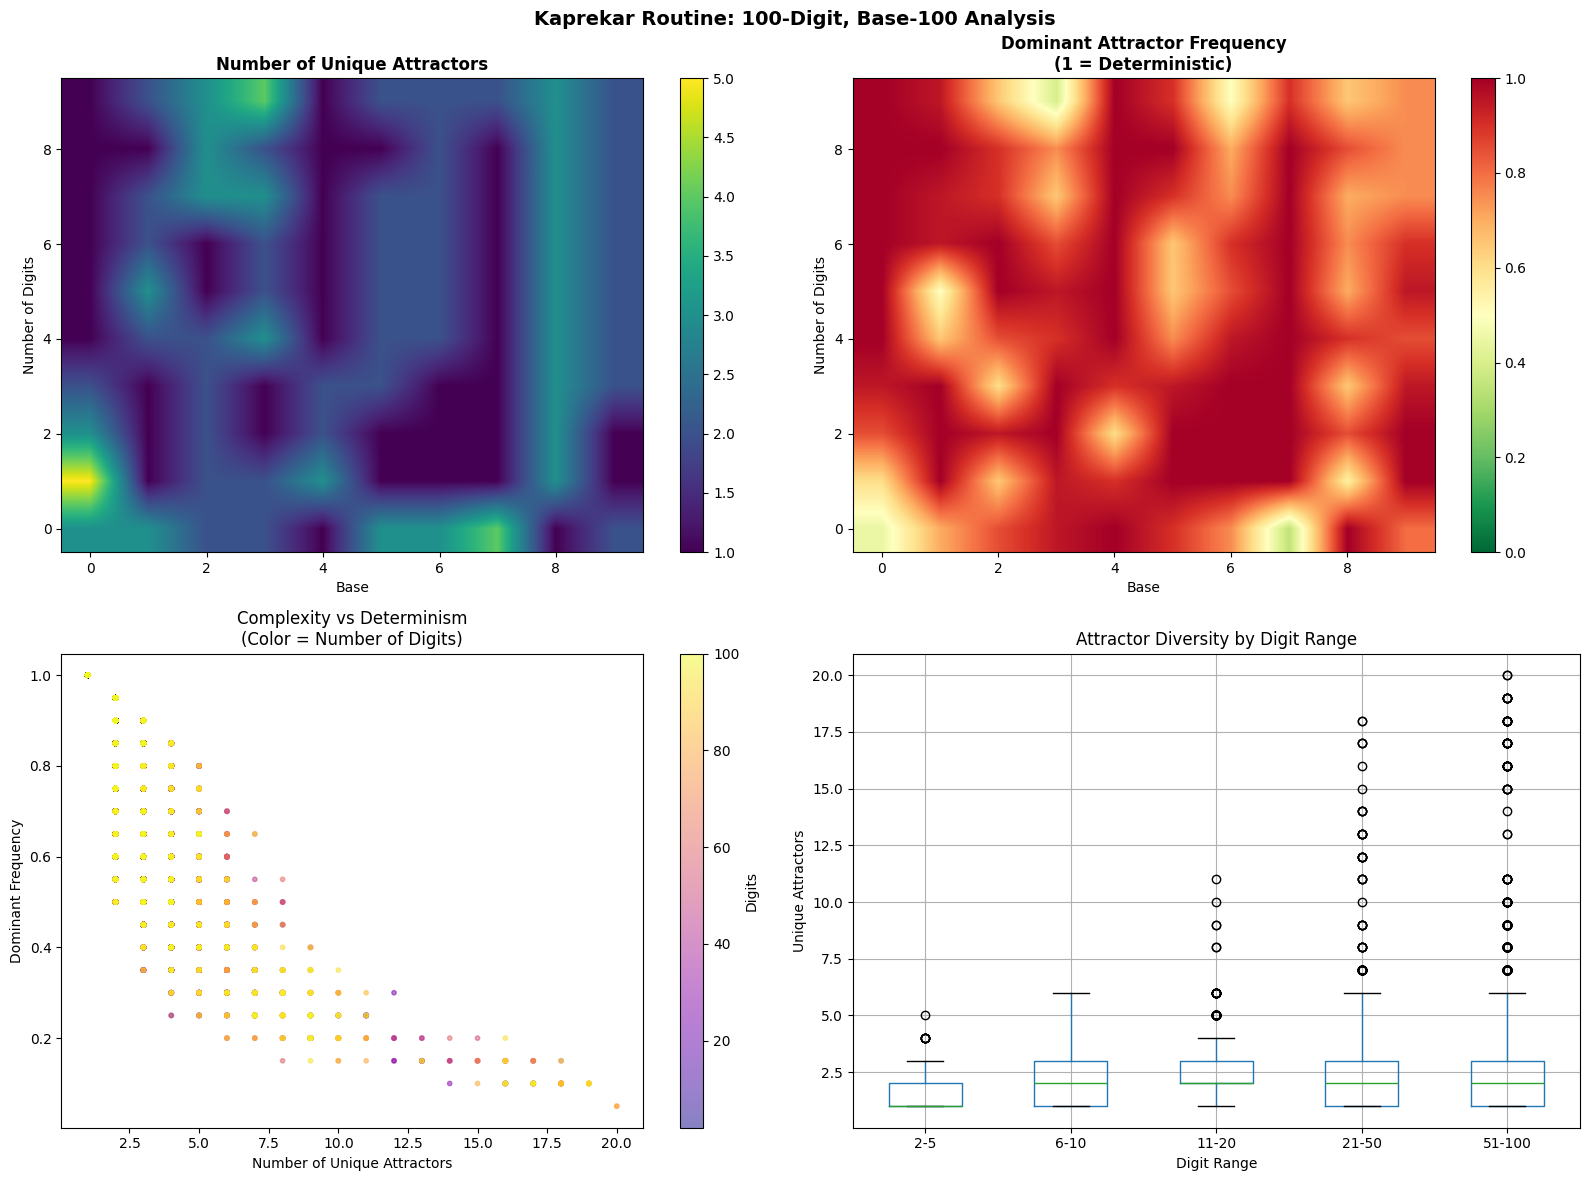


Kaprekar constants exported to: kaprekar_constants_100x100_20260607_100353.csv
Complex configurations exported to: complex_configs_100x100_20260607_100353.csv

SIMULATION COMPLETE! RESULTS READY FOR STUDY

Key files generated:
  1. Full simulation data CSV
  2. Kaprekar constants CSV (if any found)
  3. Complex configurations CSV
  4. Visualization plots

Study these to understand Kaprekar behavior across multiple digits and bases!


In [ ]:
import random
import numpy as np
from collections import Counter
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import multiprocessing as mp
from functools import partial
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# OPTIMIZED KAPREKAR FUNCTIONS FOR LARGE-SCALE SIMULATION
# ============================================================================

def digits_to_tuple(digits):
    """Convert digit list to hashable tuple."""
    return tuple(digits)

def are_all_digits_same_fast(digits):
    """Fast check if all digits are identical."""
    if len(digits) <= 1:
        return True
    first = digits[0]
    return all(d == first for d in digits)

def compute_kaprekar_step_optimized(digits, base):
    """
    Ultra-optimized Kaprekar step using integer operations.
    Avoids list copying and minimizes overhead.
    """
    n = len(digits)

    # Quick check for all same digits
    if are_all_digits_same_fast(digits):
        return [0] * n

    # Sort digits (create new lists)
    desc_digits = sorted(digits, reverse=True)
    asc_digits = desc_digits[::-1]  # Reverse is faster than sorting again

    # Convert to integer values
    desc_value = 0
    asc_value = 0

    for i in range(n):
        desc_value = desc_value * base + desc_digits[i]
        asc_value = asc_value * base + asc_digits[i]

    # Subtract
    result_value = desc_value - asc_value

    # Convert back to digits
    if result_value == 0:
        return [0] * n

    result_digits = []
    temp = result_value
    while temp > 0:
        result_digits.append(temp % base)
        temp //= base

    # Reverse and pad
    result_digits.reverse()
    while len(result_digits) < n:
        result_digits.insert(0, 0)

    return result_digits

def find_attractor_fast(start_digits, base, max_iterations=1000):
    """
    Fast attractor detection with cycle tracking.
    Returns attractor signature.
    """
    seen = {}
    current = start_digits
    iteration = 0

    while iteration < max_iterations:
        key = digits_to_tuple(current)

        if key in seen:
            # Found cycle
            cycle_start = seen[key]
            cycle_length = iteration - cycle_start

            if cycle_length == 1:
                # Fixed point - return the number
                return ('fixed', current)
            else:
                # Cycle - return cycle representation
                return ('cycle', cycle_length, current)

        seen[key] = iteration
        current = compute_kaprekar_step_optimized(current, base)
        iteration += 1

    return ('timeout', None, None)

def generate_random_digits_fast(n_digits, base):
    """
    Fast random number generation with rejection sampling.
    """
    max_attempts = 20

    for _ in range(max_attempts):
        # First digit: 1 to base-1
        digits = [random.randint(1, base - 1)]
        # Remaining digits
        digits.extend([random.randint(0, base - 1) for _ in range(n_digits - 1)])

        # Check not all same
        if not are_all_digits_same_fast(digits):
            return digits

    # Fallback: create number with at least one different digit
    digits = [random.randint(1, base - 1)]
    for i in range(n_digits - 1):
        if i == 0 and len(set(digits)) == 1:
            digits.append((digits[0] + 1) % base)
        else:
            digits.append(random.randint(0, base - 1))

    return digits

def format_attractor_for_display(attractor_data, base, max_digits_display=10):
    """
    Format attractor data for display in results.
    """
    if not attractor_data or len(attractor_data) == 0:
        return "Unknown"

    attractor_type = attractor_data[0]

    if attractor_type == 'fixed':
        digits = attractor_data[1]
        if base <= 36:
            # Traditional representation for bases <= 36
            def digit_to_char(d):
                return str(d) if d < 10 else chr(ord('A') + d - 10)
            result = ''.join(digit_to_char(d) for d in digits[:max_digits_display])
            if len(digits) > max_digits_display:
                result += "..."
            return result
        else:
            # Bracket notation for larger bases
            result = '[' + ','.join(str(d) for d in digits[:max_digits_display])
            if len(digits) > max_digits_display:
                result += ',...'
            result += ']'
            return result

    elif attractor_type == 'cycle':
        cycle_length = attractor_data[1]
        return f"Cycle_{cycle_length}"

    else:  # timeout
        return "Timeout"

def simulate_configuration(args):
    """
    Simulate a single (n_digits, base) configuration.
    Designed for parallel processing.
    """
    try:
        n_digits, base, samples = args

        if n_digits == 1:
            # Trivial case
            return {
                'n_digits': n_digits,
                'base': base,
                'unique_attractors': 1,
                'dominant_frequency': 1.0,
                'attractor_types': {'fixed': 1},
                'samples': samples,
                'most_common_attractor': '0'
            }

        attractor_counts = Counter()

        for _ in range(samples):
            start_digits = generate_random_digits_fast(n_digits, base)
            attractor_result = find_attractor_fast(start_digits, base)

            # Create a hashable key for the attractor
            if attractor_result[0] == 'fixed':
                key = ('fixed', digits_to_tuple(attractor_result[1]))
            elif attractor_result[0] == 'cycle':
                key = ('cycle', attractor_result[1])
            else:
                key = ('timeout',)

            attractor_counts[key] += 1

        # Calculate statistics
        unique_attractors = len(attractor_counts)
        dominant_freq = max(attractor_counts.values()) / samples if attractor_counts else 0

        # Get most common attractor for display
        most_common_attractor = "Unknown"
        if attractor_counts:
            most_common_key = attractor_counts.most_common(1)[0][0]
            most_common_attractor = format_attractor_for_display(most_common_key, base)

        return {
            'n_digits': n_digits,
            'base': base,
            'unique_attractors': unique_attractors,
            'dominant_frequency': dominant_freq,
            'samples': samples,
            'most_common_attractor': most_common_attractor
        }

    except Exception as e:
        # Return error result for this configuration
        print(f"Error in configuration {args}: {e}")
        return {
            'n_digits': args[0],
            'base': args[1],
            'unique_attractors': 0,
            'dominant_frequency': 0,
            'samples': args[2],
            'most_common_attractor': f"Error: {str(e)[:50]}"
        }

# ============================================================================
# MAIN SIMULATION FOR 100x100 GRID
# ============================================================================

def run_large_scale_simulation(max_digits=100, max_base=100, samples_per_config=20,
                               use_parallel=True, num_processes=None):
    """
    Run large-scale simulation for up to 100 digits and base 100.

    Parameters:
    - max_digits: Maximum number of digits (default 100)
    - max_base: Maximum base (default 100)
    - samples_per_config: Samples per configuration (reduce for speed)
    - use_parallel: Use multiprocessing for faster execution
    - num_processes: Number of parallel processes (default: CPU count)
    """

    total_configs = (max_digits - 1) * (max_base - 1)  # Excluding 1-digit
    total_simulations = total_configs * samples_per_config

    print("=" * 80)
    print("KAPREKAR ROUTINE LARGE-SCALE SIMULATION")
    print("=" * 80)
    print(f"Target: {max_digits}-digit numbers, Bases 2 to {max_base}")
    print(f"Samples per configuration: {samples_per_config}")
    print(f"Total configurations: {total_configs:,}")
    print(f"Total simulations: {total_simulations:,}")
    print(f"Parallel processing: {'Enabled' if use_parallel else 'Disabled'}")
    print("=" * 80)

    # Prepare all configurations
    configurations = []
    for n_digits in range(2, max_digits + 1):
        for base in range(2, max_base + 1):
            configurations.append((n_digits, base, samples_per_config))

    start_time = datetime.now()

    results = []

    if use_parallel and len(configurations) > 1:
        # Parallel execution
        num_cores = num_processes or min(mp.cpu_count(), 8)  # Limit to 8 cores to avoid overloading
        print(f"\nUsing {num_cores} CPU cores for parallel processing...")

        try:
            with mp.Pool(processes=num_cores) as pool:
                with tqdm(total=len(configurations), desc="Configurations") as pbar:
                    for result in pool.imap_unordered(simulate_configuration, configurations):
                        results.append(result)
                        pbar.update(1)
        except Exception as e:
            print(f"Parallel processing failed: {e}")
            print("Falling back to sequential processing...")
            use_parallel = False

    if not use_parallel:
        # Sequential execution with progress bar
        print("\nRunning sequential processing...")
        for config in tqdm(configurations, desc="Configurations"):
            result = simulate_configuration(config)
            results.append(result)

    # Convert to DataFrame
    df = pd.DataFrame(results)

    elapsed_time = (datetime.now() - start_time).total_seconds()
    print("\n" + "=" * 80)
    print(f"SIMULATION COMPLETED!")
    print(f"Total time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
    print(f"Average time per config: {elapsed_time/len(configurations):.3f} seconds")
    print("=" * 80)

    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"kaprekar_100d_100b_{timestamp}.csv"
    df.to_csv(filename, index=False)
    print(f"\nResults saved to: {filename}")

    return df

# ============================================================================
# COMPREHENSIVE ANALYSIS FOR 100x100 RESULTS
# ============================================================================

def analyze_100x100_results(df):
    """
    Deep analysis of the 100x100 simulation results.
    """
    print("\n" + "=" * 80)
    print("COMPREHENSIVE ANALYSIS: 100-DIGIT, BASE-100 RESULTS")
    print("=" * 80)

    # Filter out error results
    df_valid = df[df['unique_attractors'] > 0].copy()

    # 1. Overall statistics
    print("\n📊 OVERALL STATISTICS:")
    print(f"  • Total configurations analyzed: {len(df_valid)}")
    print(f"  • Digit range: {df_valid['n_digits'].min()} to {df_valid['n_digits'].max()}")
    print(f"  • Base range: {df_valid['base'].min()} to {df_valid['base'].max()}")
    print(f"  • Average unique attractors: {df_valid['unique_attractors'].mean():.2f}")
    print(f"  • Max unique attractors: {df_valid['unique_attractors'].max()}")
    print(f"  • Average dominant frequency: {df_valid['dominant_frequency'].mean():.3f}")

    # 2. Find Kaprekar constants (single attractor configurations)
    single_attractor = df_valid[df_valid['unique_attractors'] == 1]
    print(f"\n✨ KAPREKAR CONSTANTS FOUND: {len(single_attractor)} configurations")
    if len(single_attractor) > 0:
        print("\n  Top 20 Kaprekar constants:")
        for _, row in single_attractor.head(20).iterrows():
            print(f"    • {int(row['n_digits']):3d}-digit, base {int(row['base']):3d}: {row['most_common_attractor']}")
    else:
        print("  No single-attractor configurations found (all have multiple attractors)")

    # 3. Most complex configurations (highest diversity)
    most_complex = df_valid.nlargest(20, 'unique_attractors')
    print(f"\n🌀 MOST COMPLEX CONFIGURATIONS (Highest attractor diversity):")
    for _, row in most_complex.iterrows():
        print(f"    • {int(row['n_digits']):3d}-digit, base {int(row['base']):3d}: "
              f"{row['unique_attractors']} attractors (dominant: {row['dominant_frequency']:.2f})")

    # 4. Most deterministic configurations
    most_deterministic = df_valid.nlargest(20, 'dominant_frequency')
    print(f"\n🎯 MOST DETERMINISTIC CONFIGURATIONS (Highest predictability):")
    for _, row in most_deterministic.head(20).iterrows():
        print(f"    • {int(row['n_digits']):3d}-digit, base {int(row['base']):3d}: "
              f"{row['dominant_frequency']*100:.1f}% → {row['most_common_attractor'][:30]}")

    # 5. Trends by digit length
    print(f"\n📈 TRENDS BY DIGIT LENGTH (First 10 and Last 10):")
    digit_trends = df_valid.groupby('n_digits').agg({
        'unique_attractors': ['mean', 'std', 'max'],
        'dominant_frequency': ['mean', 'std']
    }).round(3)
    print("\nFirst 10 digit lengths:")
    print(digit_trends.head(10))
    print("\nLast 10 digit lengths:")
    print(digit_trends.tail(10))

    # 6. Trends by base
    print(f"\n📊 TRENDS BY BASE RANGE:")
    base_bins = pd.cut(df_valid['base'], bins=[1, 10, 20, 36, 50, 70, 100])
    base_trends = df_valid.groupby(base_bins).agg({
        'unique_attractors': ['mean', 'std', 'max'],
        'dominant_frequency': ['mean', 'std']
    }).round(3)
    print(base_trends)

    # 7. Find optimal configurations for study
    print(f"\n💡 RECOMMENDED CONFIGURATIONS FOR FURTHER STUDY:")

    # High diversity with reasonable digits (good for attractor landscape study)
    high_diversity = df_valid[(df_valid['unique_attractors'] > 15) & (df_valid['n_digits'] <= 20)]
    if len(high_diversity) > 0:
        print("\n  High diversity (15+ attractors, ≤20 digits):")
        for _, row in high_diversity.head(10).iterrows():
            print(f"    • {int(row['n_digits'])} digits, base {int(row['base'])}: "
                  f"{row['unique_attractors']} attractors")

    return {
        'df': df_valid,
        'single_attractor': single_attractor,
        'most_complex': most_complex,
        'digit_trends': digit_trends,
        'base_trends': base_trends
    }

def create_visualization_100x100(df):
    """
    Create visualizations specifically for 100x100 data.
    """
    # Filter out errors and use sampled data for visualization
    df_valid = df[df['unique_attractors'] > 0].copy()

    # Use smaller subset for visualization (every 10th digit and every 10th base)
    viz_df = df_valid[(df_valid['n_digits'] % 10 == 0) & (df_valid['base'] % 10 == 0)]

    if len(viz_df) < 10:
        print("Not enough data for visualization, using all data...")
        viz_df = df_valid

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Heatmap of unique attractors
    try:
        pivot_attractors = viz_df.pivot(index='n_digits', columns='base', values='unique_attractors')
        im1 = axes[0, 0].imshow(pivot_attractors.values, aspect='auto', cmap='viridis',
                                interpolation='bilinear', origin='lower')
        axes[0, 0].set_title('Number of Unique Attractors', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Base')
        axes[0, 0].set_ylabel('Number of Digits')
        plt.colorbar(im1, ax=axes[0, 0])
    except Exception as e:
        axes[0, 0].text(0.5, 0.5, f'Heatmap error: {str(e)[:50]}',
                       ha='center', va='center')
        axes[0, 0].set_title('Number of Unique Attractors (Data Error)')

    # 2. Heatmap of dominant frequency
    try:
        pivot_dominant = viz_df.pivot(index='n_digits', columns='base', values='dominant_frequency')
        im2 = axes[0, 1].imshow(pivot_dominant.values, aspect='auto', cmap='RdYlGn_r',
                                interpolation='bilinear', origin='lower', vmin=0, vmax=1)
        axes[0, 1].set_title('Dominant Attractor Frequency\n(1 = Deterministic)', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Base')
        axes[0, 1].set_ylabel('Number of Digits')
        plt.colorbar(im2, ax=axes[0, 1])
    except Exception as e:
        axes[0, 1].text(0.5, 0.5, f'Heatmap error: {str(e)[:50]}',
                       ha='center', va='center')
        axes[0, 1].set_title('Dominant Frequency (Data Error)')

    # 3. Scatter plot: Complexity vs Determinism
    scatter = axes[1, 0].scatter(df_valid['unique_attractors'], df_valid['dominant_frequency'],
                                 c=df_valid['n_digits'], cmap='plasma', alpha=0.5, s=10)
    axes[1, 0].set_xlabel('Number of Unique Attractors')
    axes[1, 0].set_ylabel('Dominant Frequency')
    axes[1, 0].set_title('Complexity vs Determinism\n(Color = Number of Digits)')
    plt.colorbar(scatter, ax=axes[1, 0], label='Digits')

    # 4. Box plot by digit ranges
    try:
        df_valid['digit_group'] = pd.cut(df_valid['n_digits'], bins=[0, 5, 10, 20, 50, 100],
                                       labels=['2-5', '6-10', '11-20', '21-50', '51-100'])
        df_valid.boxplot(column='unique_attractors', by='digit_group', ax=axes[1, 1])
        axes[1, 1].set_title('Attractor Diversity by Digit Range')
        axes[1, 1].set_xlabel('Digit Range')
        axes[1, 1].set_ylabel('Unique Attractors')
    except Exception as e:
        axes[1, 1].text(0.5, 0.5, f'Boxplot error: {str(e)[:50]}',
                       ha='center', va='center')
        axes[1, 1].set_title('Attractor Diversity (Data Error)')

    plt.suptitle('Kaprekar Routine: 100-Digit, Base-100 Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """
    Main execution for 100x100 simulation.
    """
    print("\n" + "=" * 80)
    print("KAPREKAR ROUTINE: 100-DIGIT, BASE-100 MONTE CARLO SIMULATION")
    print("=" * 80)

    # Simulation parameters (adjust based on your computational resources)
    MAX_DIGITS = 100
    MAX_BASE = 100
    SAMPLES_PER_CONFIG = 20  # Reduced for 100x100 grid

    print(f"\n⚠️  IMPORTANT NOTICE:")
    print(f"   This will simulate {(MAX_DIGITS - 1) * (MAX_BASE - 1):,} configurations")
    print(f"   with {SAMPLES_PER_CONFIG} samples each = {(MAX_DIGITS - 1) * (MAX_BASE - 1) * SAMPLES_PER_CONFIG:,} total simulations")
    print(f"\n   Estimated time: ~20-40 minutes on a modern multi-core CPU")

    # For testing, you can use smaller values first
    test_mode = input("\nRun in test mode with smaller range first? (y/n): ").lower()
    if test_mode == 'y':
        MAX_DIGITS = 20
        MAX_BASE = 20
        SAMPLES_PER_CONFIG = 10
        print(f"\nTest mode: {MAX_DIGITS} digits, base {MAX_BASE}, {SAMPLES_PER_CONFIG} samples")

    response = input("\nProceed with simulation? (y/n): ").lower()
    if response != 'y':
        print("Simulation cancelled.")
        return

    # Run simulation
    df = run_large_scale_simulation(
        max_digits=MAX_DIGITS,
        max_base=MAX_BASE,
        samples_per_config=SAMPLES_PER_CONFIG,
        use_parallel=True,
        num_processes=None  # Use all available cores (capped at 8)
    )

    # Analyze results
    analysis_results = analyze_100x100_results(df)

    # Create visualizations
    print("\n" + "=" * 80)
    print("GENERATING VISUALIZATIONS")
    print("=" * 80)
    create_visualization_100x100(df)

    # Export key findings
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Export Kaprekar constants
    if len(analysis_results['single_attractor']) > 0:
        constants_file = f"kaprekar_constants_{MAX_DIGITS}x{MAX_BASE}_{timestamp}.csv"
        analysis_results['single_attractor'].to_csv(constants_file, index=False)
        print(f"\nKaprekar constants exported to: {constants_file}")

    # Export complex configurations
    complex_file = f"complex_configs_{MAX_DIGITS}x{MAX_BASE}_{timestamp}.csv"
    analysis_results['most_complex'].to_csv(complex_file, index=False)
    print(f"Complex configurations exported to: {complex_file}")

    print("\n" + "=" * 80)
    print("SIMULATION COMPLETE! RESULTS READY FOR STUDY")
    print("=" * 80)
    print("\nKey files generated:")
    print("  1. Full simulation data CSV")
    print("  2. Kaprekar constants CSV (if any found)")
    print("  3. Complex configurations CSV")
    print("  4. Visualization plots")
    print("\nStudy these to understand Kaprekar behavior across multiple digits and bases!")

if __name__ == "__main__":
    main()

In [ ]:
# Download the high-base simulation results CSV
files.download('kaprekar_constants_100x100_20260607_100353.csv')
files.download('complex_configs_100x100_20260607_100353.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>